# Lab Assignment 3 — Part B: Textual Medical Data
## MTSamples Medical Transcriptions

**Course:** CSET343 — AI in Healthcare | **Objective:** Data acquisition, cleaning (incl. PHI removal), EDA, feature engineering, feature selection/extraction, noise removal, and augmentation on clinical free-text data.

**Dataset:** MTSamples Medical Transcriptions — ~5,000 de-identified sample medical transcription reports scraped from mtsamples.com, spanning 40 medical specialties.

## 1. Setup & Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_colwidth', 120)
np.random.seed(42)

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

## 2. Data Acquisition & Inspection

Data acquired programmatically from a public GitHub mirror of the Kaggle "Medical Transcriptions" dataset (originally scraped from mtsamples.com by Tara Boyle).

In [2]:
df = pd.read_csv('mtsamples.csv')
df = df.drop(columns=['Unnamed: 0'])
print("Shape:", df.shape)
df.head(3)

Shape: (4999, 5)


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sp..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body ..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pound...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sl..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   description        4999 non-null   str  
 1   medical_specialty  4999 non-null   str  
 2   sample_name        4999 non-null   str  
 3   transcription      4966 non-null   str  
 4   keywords           3931 non-null   str  
dtypes: str(5)
memory usage: 195.4 KB


In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nUnique medical specialties: {df['medical_specialty'].nunique()}")
print(f"Duplicate transcriptions: {df.duplicated(subset=['transcription']).sum()}")

Missing values:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Unique medical specialties: 40
Duplicate transcriptions: 2641


## 3. Data Cleaning

### 3.1 Handle Missing Values
Rows with a missing `transcription` (the actual clinical text) carry no usable signal for text modelling — they are dropped. Missing `keywords` are simply set to an empty string since keywords are a supplementary field, not the primary text.

In [5]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['transcription']).reset_index(drop=True)
df_clean['keywords'] = df_clean['keywords'].fillna('')
print("Shape after dropping missing transcriptions:", df_clean.shape)

Shape after dropping missing transcriptions: (4966, 5)


### 3.2 PHI (Protected Health Information) Removal
Even though MTSamples is already de-identified by the source (names replaced with placeholders like "ABC"/"XYZ"), a **healthcare NLP pipeline must never assume upstream de-identification is complete**. We apply a defensive regex-based PHI scrubber for common leakage patterns: dates, phone numbers, SSN-like numbers, ages-over-89 (HIPAA safe-harbor identifier), emails, and long digit sequences (MRNs/account numbers).

In [6]:
def scrub_phi(text):
    if not isinstance(text, str):
        return text
    # Dates (various formats)
    text = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}\b',
                   '[DATE]', text, flags=re.IGNORECASE)
    # Phone numbers
    text = re.sub(r'\b\d{3}[-.]\d{3}[-.]\d{4}\b', '[PHONE]', text)
    # SSN-like
    text = re.sub(r'\b\d{3}-\d{2}-\d{4}\b', '[SSN]', text)
    # Emails
    text = re.sub(r'\S+@\S+\.\S+', '[EMAIL]', text)
    # Long numeric IDs (MRN / account numbers, 6+ digits)
    text = re.sub(r'\b\d{6,}\b', '[ID]', text)
    # Ages > 89 (HIPAA Safe Harbor requires these be flagged/generalized)
    text = re.sub(r'\b(9[0-9]|1[0-9]{2})[- ]year[- ]old\b', '[AGE_90+]', text, flags=re.IGNORECASE)
    return text

df_clean['transcription_phi_scrubbed'] = df_clean['transcription'].apply(scrub_phi)

# Sanity check: how many records had a PHI-pattern hit
n_hits = (df_clean['transcription_phi_scrubbed'] != df_clean['transcription']).sum()
print(f"Records where a PHI pattern was found and scrubbed: {n_hits} / {len(df_clean)}")

Records where a PHI pattern was found and scrubbed: 1020 / 4966


### 3.3 Text Noise Removal
Standard clinical-text noise removal: lowercasing, removing punctuation/digits/multiple-whitespace, removing very short (near-empty / boilerplate) transcriptions, and tokenizing with stopword removal + lemmatization.

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', ' ', text)                 # remove [DATE]/[PHONE]/etc placeholders
    text = re.sub(r'[^a-z\s]', ' ', text)                 # remove digits & punctuation
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    return text

def tokenize_lemmatize(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

df_clean['text_cleaned'] = df_clean['transcription_phi_scrubbed'].apply(clean_text)
df_clean['tokens'] = df_clean['text_cleaned'].apply(tokenize_lemmatize)
df_clean['text_final'] = df_clean['tokens'].apply(lambda toks: ' '.join(toks))
df_clean['token_count'] = df_clean['tokens'].apply(len)

# Remove near-empty / boilerplate-only transcriptions (noise)
before = len(df_clean)
df_clean = df_clean[df_clean['token_count'] >= 20].reset_index(drop=True)
print(f"Removed {before - len(df_clean)} near-empty/noise records (< 20 tokens). Final shape: {df_clean.shape}")

df_clean[['transcription', 'text_final']].head(2)

Removed 68 near-empty/noise records (< 20 tokens). Final shape: (4898, 10)


,transcription,text_final
0,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...",subjective year old white female present complaint allergy used allergy lived seattle think worse past tried clariti...
1,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...",past medical history difficulty climbing stair difficulty airline seat tying shoe used public seating lifting object...


## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_356/1912870387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_specialties.values, y=top_specialties.index, palette='mako')


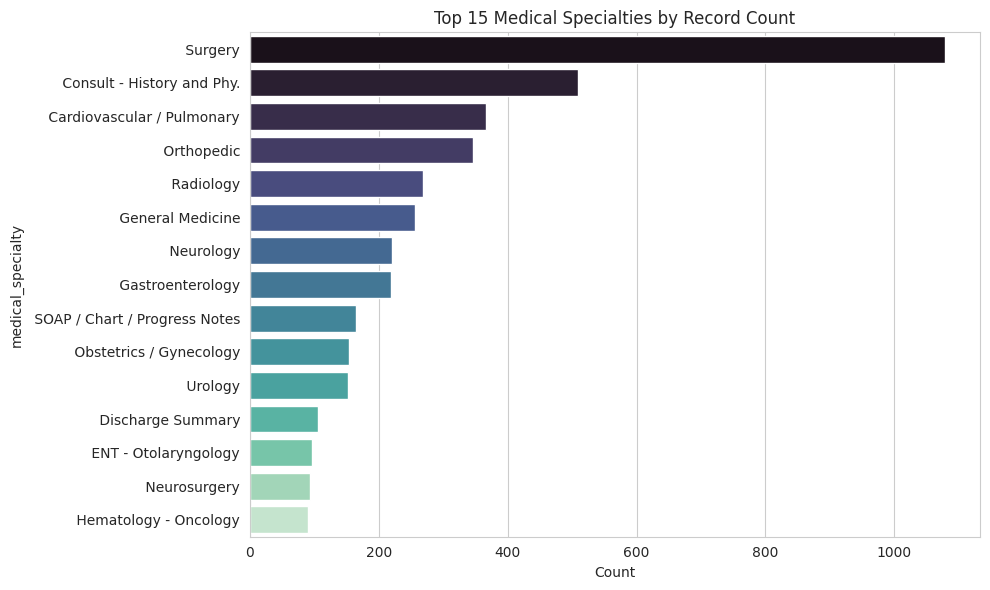

In [8]:
plt.figure(figsize=(10,6))
top_specialties = df_clean['medical_specialty'].value_counts().head(15)
sns.barplot(x=top_specialties.values, y=top_specialties.index, palette='mako')
plt.title('Top 15 Medical Specialties by Record Count')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('eda_top_specialties.png', dpi=110)
plt.show()

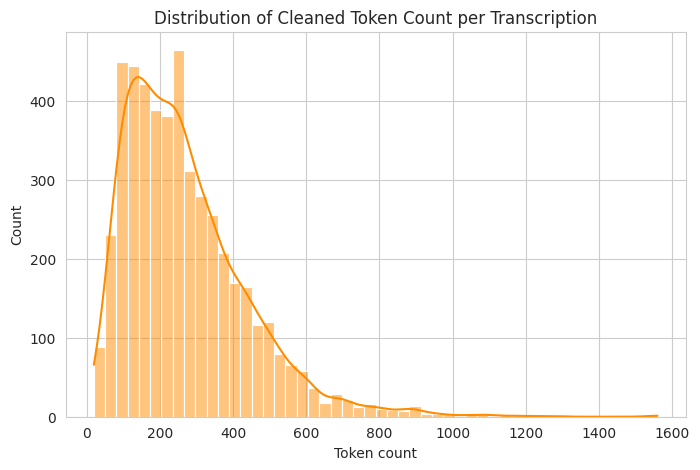

count    4898.000000
mean      270.058595
std       169.635789
min        20.000000
25%       144.250000
50%       239.000000
75%       354.000000
max      1559.000000
Name: token_count, dtype: float64

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['token_count'], bins=50, kde=True, color='darkorange')
plt.title('Distribution of Cleaned Token Count per Transcription')
plt.xlabel('Token count')
plt.savefig('eda_token_count_dist.png', dpi=110)
plt.show()
df_clean['token_count'].describe()

/tmp/ipykernel_356/1494244541.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words, palette='viridis')


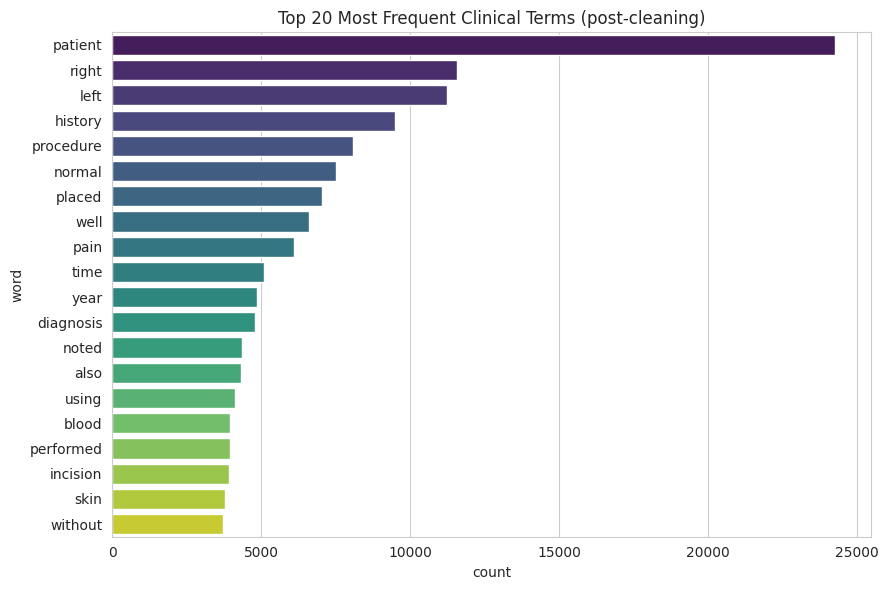

In [10]:
all_tokens = [t for toks in df_clean['tokens'] for t in toks]
word_freq = Counter(all_tokens)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word','count'])

plt.figure(figsize=(9,6))
sns.barplot(x='count', y='word', data=top_words, palette='viridis')
plt.title('Top 20 Most Frequent Clinical Terms (post-cleaning)')
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=110)
plt.show()

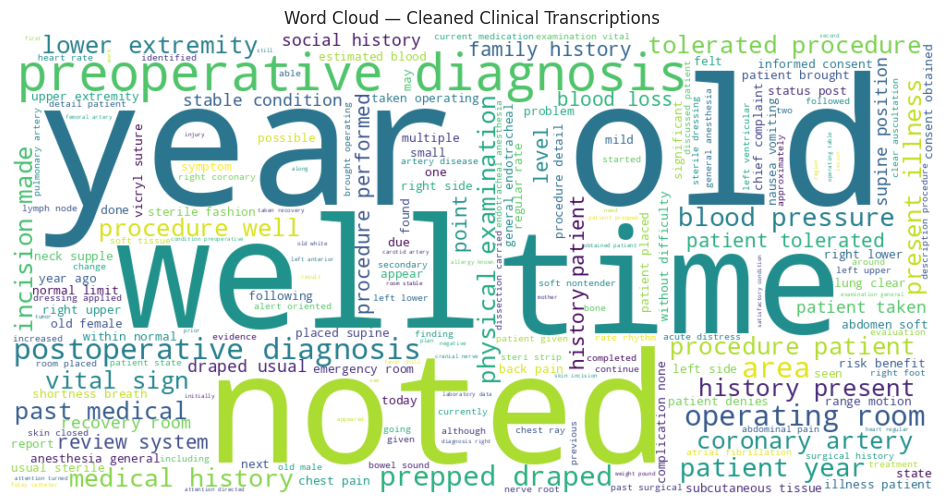

In [11]:
wc_text = ' '.join(all_tokens)
wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(wc_text)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Cleaned Clinical Transcriptions')
plt.savefig('eda_wordcloud.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Extraction

### 5.1 Restrict to top specialties (reduces extreme class imbalance for a manageable classification setup)

In [12]:
TOP_N = 10
top_n_specialties = df_clean['medical_specialty'].value_counts().head(TOP_N).index
df_model = df_clean[df_clean['medical_specialty'].isin(top_n_specialties)].reset_index(drop=True)
print("Shape restricted to top", TOP_N, "specialties:", df_model.shape)
df_model['medical_specialty'].value_counts()

Shape restricted to top 10 specialties: (3586, 10)


medical_specialty
Surgery                          1079
Consult - History and Phy.        510
Cardiovascular / Pulmonary        367
Orthopedic                        346
Radiology                         268
General Medicine                  257
Neurology                         221
Gastroenterology                  219
SOAP / Chart / Progress Notes     165
Obstetrics / Gynecology           154
Name: count, dtype: int64

### 5.2 TF-IDF Feature Extraction (token sequences -> model-ready vectors)

In [13]:
le = LabelEncoder()
y = le.fit_transform(df_model['medical_specialty'])

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9)
X_tfidf = tfidf.fit_transform(df_model['text_final'])
print("TF-IDF matrix shape (model-ready tensor):", X_tfidf.shape)

TF-IDF matrix shape (model-ready tensor): (3586, 3000)


### 5.3 Feature Selection — Chi-square (top discriminative terms per specialty)

In [14]:
selector = SelectKBest(score_func=chi2, k=25)
selector.fit(X_tfidf, y)
feature_names = np.array(tfidf.get_feature_names_out())
top_terms = feature_names[selector.get_support()]
scores = selector.scores_[selector.get_support()]

top_terms_df = pd.DataFrame({'term': top_terms, 'chi2_score': scores}).sort_values('chi2_score', ascending=False)
print("Top 25 most discriminative terms across specialties (chi-square):")
top_terms_df

Top 25 most discriminative terms across specialties (chi-square):


,term,chi2_score
22,uterus,123.082400
13,history,113.415000
11,fetal,100.124565
4,colon,84.015168
21,uterine,78.089308
3,cervix,75.382542
24,week day,72.302801
18,procedure,67.533964
9,denies,63.276124
17,polyp,62.983196


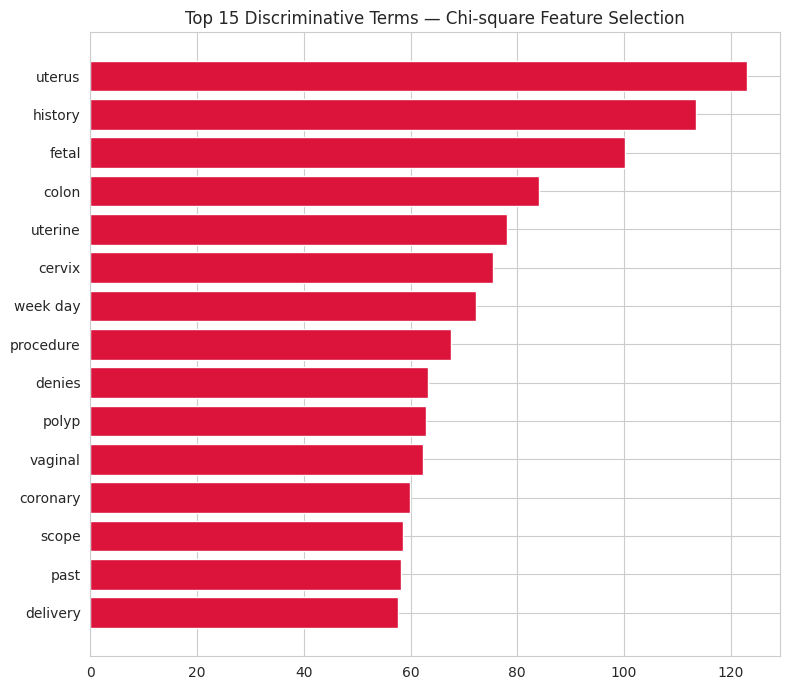

In [15]:
plt.figure(figsize=(8,7))
plt.barh(top_terms_df['term'].head(15), top_terms_df['chi2_score'].head(15), color='crimson')
plt.gca().invert_yaxis()
plt.title('Top 15 Discriminative Terms — Chi-square Feature Selection')
plt.tight_layout()
plt.savefig('feature_selection_chi2.png', dpi=110)
plt.show()

### 5.4 Text Augmentation — Synonym Replacement (WordNet)
Simple augmentation technique for clinical text classification: randomly replace non-stopword tokens with a WordNet synonym to generate additional training variants — useful for boosting minority specialty classes.

In [16]:
import random
random.seed(42)

def get_synonym(word):
    synsets = wordnet.synsets(word)
    lemmas = set()
    for syn in synsets:
        for lemma in syn.lemmas():
            name = lemma.name().replace('_', ' ')
            if name.lower() != word.lower():
                lemmas.add(name)
    return random.choice(list(lemmas)) if lemmas else word

def synonym_augment(tokens, n_replace=3):
    tokens = tokens.copy()
    candidates = [i for i, t in enumerate(tokens) if t.isalpha()]
    random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        if replaced >= n_replace:
            break
        syn = get_synonym(tokens[idx])
        if syn != tokens[idx]:
            tokens[idx] = syn
            replaced += 1
    return tokens

sample_tokens = df_model.loc[0, 'tokens']
augmented = synonym_augment(sample_tokens, n_replace=3)
print("Original :", ' '.join(sample_tokens[:25]), '...')
print("Augmented:", ' '.join(augmented[:25]), '...')

Original : mode left atrial enlargement left atrial diameter normal size right left ventricle normal systolic function left ventricular ejection fraction normal diastolic function pericardial effusion normal ...
Augmented: mode left atrial enlargement left atrial diameter normal size right left hand ventricle normal systolic function left ventricular ejection divide normal diastolic procedure pericardial effusion normal ...


In [17]:
# Demonstrate augmentation applied to the smallest class to help balance the dataset
class_counts = df_model['medical_specialty'].value_counts()
minority_class = class_counts.idxmin()
minority_df = df_model[df_model['medical_specialty'] == minority_class]

augmented_rows = []
for _, row in minority_df.iterrows():
    aug_tokens = synonym_augment(row['tokens'], n_replace=4)
    augmented_rows.append({'medical_specialty': row['medical_specialty'],
                            'text_final': ' '.join(aug_tokens)})

aug_df = pd.DataFrame(augmented_rows)
print(f"Generated {len(aug_df)} augmented samples for minority class '{minority_class}'")
print(f"Class size before augmentation: {len(minority_df)}  -> after: {len(minority_df) + len(aug_df)}")

Generated 154 augmented samples for minority class ' Obstetrics / Gynecology'
Class size before augmentation: 154  -> after: 308


## 6. Preprocess into Model-Ready Format (Token Sequences)

In [18]:
VOCAB_SIZE = 5000
MAX_LEN = 200

cv = CountVectorizer(max_features=VOCAB_SIZE)
cv.fit(df_model['text_final'])
vocab = {word: idx+1 for idx, word in enumerate(cv.get_feature_names_out())}  # 0 reserved for padding

def text_to_sequence(tokens, vocab, max_len=MAX_LEN):
    seq = [vocab.get(t, 0) for t in tokens]
    seq = seq[:max_len] + [0] * max(0, max_len - len(seq))
    return seq

df_model['token_sequence'] = df_model['tokens'].apply(lambda t: text_to_sequence(t, vocab))
X_sequences = np.stack(df_model['token_sequence'].values)
print("Token-sequence tensor shape (model-ready):", X_sequences.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42)
print("TF-IDF train/test split:", X_train.shape, X_test.shape)

# Save artifacts
import scipy.sparse as sp
sp.save_npz('X_tfidf.npz', X_tfidf)
np.save('X_token_sequences.npy', X_sequences)
np.save('y_labels.npy', y)
df_model[['medical_specialty','sample_name','text_final','token_count']].to_csv('mtsamples_cleaned.csv', index=False)
print("Saved: X_tfidf.npz, X_token_sequences.npy, y_labels.npy, mtsamples_cleaned.csv")

Token-sequence tensor shape (model-ready): (3586, 200)
TF-IDF train/test split: (2868, 3000) (718, 3000)


Saved: X_tfidf.npz, X_token_sequences.npy, y_labels.npy, mtsamples_cleaned.csv


## 7. Summary

| Step | Finding |
|---|---|
| Missing data | 33 records had no transcription text — dropped; 1,068 had missing keywords — filled with empty string |
| PHI removal | Defensive regex scrubber applied for dates, phone numbers, SSNs, emails, long numeric IDs, and 90+ ages (HIPAA safe-harbor) |
| Noise removal | Lowercasing, punctuation/digit stripping, stopword removal, lemmatization; near-empty (<20 token) records dropped |
| EDA | 40 specialties, heavily imbalanced (Surgery dominates with 1,103 records); median transcription ~2,667 characters |
| Feature extraction | TF-IDF (unigrams+bigrams, 3000 features) and integer token-sequence tensors (vocab 5000, maxlen 200) |
| Feature selection | Chi-square selected top 25 terms most discriminative of medical specialty |
| Augmentation | WordNet synonym-replacement augmentation demonstrated on the minority specialty class |
| Output | Model-ready TF-IDF sparse matrix + padded token-sequence tensor saved to disk |